# Chapter 02: Profiling a Transformer Block

**Goal:** Understand where time actually goes in a transformer layer — which operations are memory-bound vs compute-bound?

We use Chapter 1's roofline model to classify each operation. Operations below the ridge point (~134 FLOPS/byte on our A100) are memory-bound; above it, they're compute-bound.

**Model:** LLaMA-3.2-1B — a modern architecture with RMSNorm, SwiGLU, GQA, and RoPE.

**Approach:** Fill in every `# YOUR CODE` section yourself — that's the learning.

**Hardware:** A100 80GB SXM4
- Measured HBM bandwidth: 1774 GB/s
- FP16 TFLOPS: 237
- Ridge point: ~134 FLOPS/byte

## 1. Setup: Load a Transformer Model

We use **LLaMA-3.2-1B** — a modern transformer with the same building blocks in every state-of-the-art model:
RMSNorm, SwiGLU FFN, Grouped Query Attention (GQA), and Rotary Position Embedding (RoPE).

**7 linear layers per block:**
- Attention: `q_proj`(2048->2048), `k_proj`(2048->512), `v_proj`(2048->512), `o_proj`(2048->2048)
- SwiGLU FFN: `gate_proj`(2048->8192), `up_proj`(2048->8192), `down_proj`(8192->2048)

Notice K and V projections output 512, not 2048 — that's GQA (8 KV heads x 64 dim vs 32 Q heads x 64 dim).

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.profiler import profile, ProfilerActivity

device = torch.device('cuda')
print(f"Device: {torch.cuda.get_device_name()}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [32]:
from transformers import AutoModelForCausalLM, AutoConfig

model_id = "meta-llama/Llama-3.2-1B"
config = AutoConfig.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
model.eval()

block = model.model.layers[0]

d_model = config.hidden_size
n_heads = config.num_attention_heads
n_kv_heads = config.num_key_value_heads
d_head = d_model // n_heads
d_ff = config.intermediate_size

print(f"d_model: {d_model}")
print(f"Q heads: {n_heads}, KV heads: {n_kv_heads} (GQA {n_heads // n_kv_heads}:1)")
print(f"d_head: {d_head}")
print(f"d_ff: {d_ff} ({d_ff / d_model:.1f}x d_model)")
print(f"Layers: {config.num_hidden_layers}")
print(f"\n{block}")

d_model: 2048
Q heads: 32, KV heads: 8 (GQA 4:1)
d_head: 64
d_ff: 8192 (4.0x d_model)
Layers: 16

LlamaDecoderLayer(
  (self_attn): LlamaSdpaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2048, out_features=512, bias=False)
    (v_proj): Linear(in_features=2048, out_features=512, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (rotary_emb): LlamaRotaryEmbedding()
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
)


## 2. Walk the Forward Pass

One transformer block, input `(1, 512, 2048)`:

| Op | Output shape | Note |
|----|-------------|------|
| RMSNorm | (1, 512, 2048) | elementwise normalize, no shape change |
| q_proj | (1, 512, 2048) | 32 heads × 64 |
| k_proj | (1, 512, 512) | 8 KV heads × 64 — GQA, 4× smaller |
| v_proj | (1, 512, 512) | 8 KV heads × 64 — GQA |
| reshape Q/K/V | (1,32,512,64) / (1,8,512,64) | split into per-head tensors |
| RoPE | in-place on Q, K | rotates by position, no shape change |
| QK^T | (1, 32, 512, 512) | score matrix grows as S² |
| softmax + @V | (1, 32, 512, 64) | weighted sum of values |
| o_proj | (1, 512, 2048) | concat heads, project back to d_model |
| RMSNorm | (1, 512, 2048) | before FFN |
| gate_proj + up_proj | (1, 512, 8192) each | SwiGLU: two parallel expansions |
| SiLU(gate) × up | (1, 512, 8192) | elementwise gating |
| down_proj | (1, 512, 2048) | back to d_model |

Block output: `(1, 512, 2048)` — same as input, passed to next of 16 blocks.

In [33]:
seq_len = 512
batch_size = 1

# hidden-state tensor
x = torch.randn(batch_size, seq_len, d_model, dtype=torch.float16, device=device)

# Pre-compute RoPE embeddings (cos, sin) — required by LLaMA attention
position_ids = torch.arange(seq_len, device=device).unsqueeze(0)
rotary_emb = model.model.layers[0].self_attn.rotary_emb
position_embeddings = rotary_emb(x, position_ids)

print(f"Input shape: {x.shape}")
print(f"Input size: {x.numel() * 2 / 1e6:.2f} MB (FP16)")
print(f"Position embeddings: cos {position_embeddings[0].shape}, sin {position_embeddings[1].shape}")

# Warmup
with torch.no_grad():
    for _ in range(5):
        _ = block(x, position_embeddings=position_embeddings, use_cache=False)

Input shape: torch.Size([1, 512, 2048])
Input size: 2.10 MB (FP16)
Position embeddings: cos torch.Size([1, 512, 64]), sin torch.Size([1, 512, 64])


## 3. Arithmetic Intensity — What Does Each Op Cost?

For each operation in the forward pass, we'll calculate:
- **FLOPs** — how many multiply-adds happen
- **Bytes** — how much data moves between HBM and the compute cores
- **Intensity** = FLOPs ÷ Bytes

Then compare each to the A100 ridge point (**~134 FLOPS/byte**). Less than ridge = memory-bound. More than ridge = compute-bound.

---

**For a matmul `(M, K) @ (K, N)`:**
- FLOPs: `2 × M × K × N` — one multiply + one add per K element, for each of M×N output positions
- Bytes: `(M×K + K×N + M×N) × 2` — load input, load weights, write output (FP16 = 2 bytes each)
- Intensity = FLOPs ÷ Bytes

**For elementwise ops on an `(M, N)` tensor:**
- FLOPs: `M × N × ops_per_element`
- Bytes: `M × N × 2 × passes` — each full read or write of the tensor counts as one pass

In [34]:
S = seq_len   # 512
D = d_model   # 2048
D_ff = d_ff   # 8192
H = n_heads   # 32
H_kv = n_kv_heads  # 8
D_h = d_head  # 64

ops_analysis = []

# =====================================================
# Attention linear projections
# =====================================================

# Q projection: (S, D) @ (D, D) → (S, D)
# Three tensors travel to/from HBM: input (S×D), weights (D×D), output (S×D) — all FP16 (2 bytes)
flops_q = 2 * S * D * D 
bytes_q = (S*D + D*D + S*D) * 2
ops_analysis.append({'Operation': 'Q projection', 'FLOPs': flops_q, 'Bytes': bytes_q,
    'Intensity': flops_q / bytes_q, 'Category': 'Linear'})

# K projection (GQA): (S, D) @ (D, kv_dim) → (S, kv_dim)
# GQA: 8 KV heads × 64 = 512. The weight matrix is 4× smaller than Q's.
kv_dim = D_h * H_kv
flops_k = 2 * S * D * kv_dim
bytes_k = (S*D + D*kv_dim + S*kv_dim) * 2
ops_analysis.append({'Operation': 'K projection (GQA)', 'FLOPs': flops_k, 'Bytes': bytes_k,
    'Intensity': flops_k / bytes_k, 'Category': 'Linear'})

# V projection: same dimensions as K
ops_analysis.append({'Operation': 'V projection (GQA)', 'FLOPs': flops_k, 'Bytes': bytes_k,
    'Intensity': flops_k / bytes_k, 'Category': 'Linear'})

# O projection: (S, D) @ (D, D) → same shape as Q
ops_analysis.append({'Operation': 'O projection', 'FLOPs': flops_q, 'Bytes': bytes_q,
    'Intensity': flops_q / bytes_q, 'Category': 'Linear'})

# =====================================================
# SwiGLU FFN (3 projections)
# =====================================================

# gate_proj and up_proj: both (S, D) @ (D, D_ff) → (S, D_ff)
flops_gate = 2 * S * D * D_ff
bytes_gate = (S*D + D*D_ff + S*D_ff) * 2
ops_analysis.append({'Operation': 'FFN gate_proj', 'FLOPs': flops_gate, 'Bytes': bytes_gate,
    'Intensity': flops_gate / bytes_gate, 'Category': 'Linear'})
ops_analysis.append({'Operation': 'FFN up_proj', 'FLOPs': flops_gate, 'Bytes': bytes_gate,
    'Intensity': flops_gate / bytes_gate, 'Category': 'Linear'})

# down_proj: (S, D_ff) @ (D_ff, D) → (S, D)  — input is now D_ff wide
flops_down = 2 * S * D_ff * D
bytes_down = (S*D_ff + D_ff*D + S*D) * 2
ops_analysis.append({'Operation': 'FFN down_proj', 'FLOPs': flops_down, 'Bytes': bytes_down,
    'Intensity': flops_down / bytes_down, 'Category': 'Linear'})

# =====================================================
# Attention operations
# =====================================================

# QK^T: per head (S, D_h) @ (D_h, S) → (S, S), across H query heads
# Matmul is (S, D_h) @ (D_h, S): M=S, K=D_h, N=S  →  2 * S * D_h * S per head
flops_qk = H * 2 * S * D_h * S
bytes_qk = H * (S*D_h + D_h*S + S*S) * 2
ops_analysis.append({'Operation': 'QK^T (all heads)', 'FLOPs': flops_qk, 'Bytes': bytes_qk,
    'Intensity': flops_qk / bytes_qk, 'Category': 'Attention'})

# Softmax: ~3 ops per element (exp, sum, divide) on the (H, S, S) score matrix
flops_softmax = 3 * H * S * S
bytes_softmax = H * (S*S + S*S) * 2  # read scores + write normalized scores
ops_analysis.append({'Operation': 'Softmax', 'FLOPs': flops_softmax, 'Bytes': bytes_softmax,
    'Intensity': flops_softmax / bytes_softmax, 'Category': 'Attention'})

# Attn @ V: per head (S, S) @ (S, D_h) → (S, D_h): M=S, K=S, N=D_h  →  2*S*S*D_h per head
# Same total FLOPs as QK^T. Bytes also equal: both move 2*S*D_h + S*S tensors per head.
ops_analysis.append({'Operation': 'Attn @ V', 'FLOPs': flops_qk, 'Bytes': bytes_qk,
    'Intensity': flops_qk / bytes_qk, 'Category': 'Attention'})

# =====================================================
# Elementwise operations
# =====================================================

# RMSNorm: ~5 ops per element (square, mean, rsqrt, multiply, scale) on (S, D)
flops_rmsnorm = 5 * S * D
bytes_rmsnorm = (S*D + S*D) * 2  # read input, write output
ops_analysis.append({'Operation': 'RMSNorm', 'FLOPs': flops_rmsnorm, 'Bytes': bytes_rmsnorm,
    'Intensity': flops_rmsnorm / bytes_rmsnorm, 'Category': 'Elementwise'})

# SiLU + gate multiply: SiLU(gate) * up — reads gate and up tensors, writes one output
# SiLU(x) = x * sigmoid(x): ~3 ops for sigmoid + 1 for x*sig(x) + 1 for *up = 5 ops/element
flops_silu = 5 * S * D_ff
bytes_silu = (S*D_ff + S*D_ff + S*D_ff) * 2  # read gate + read up + write output
ops_analysis.append({'Operation': 'SiLU + gate mul', 'FLOPs': flops_silu, 'Bytes': bytes_silu,
    'Intensity': flops_silu / bytes_silu, 'Category': 'Elementwise'})

df = pd.DataFrame(ops_analysis)
df['FLOPs (M)'] = df['FLOPs'] / 1e6
df['Bytes (MB)'] = df['Bytes'] / 1e6

print(f"Arithmetic Intensity — LLaMA-3.2-1B (seq={S})")
print(f"d_model={D}, d_ff={D_ff}, {H} Q heads, {H_kv} KV heads, d_head={D_h}")
print("="*90)
print(df[['Operation', 'FLOPs (M)', 'Bytes (MB)', 'Intensity', 'Category']].to_string(index=False))
print("="*90)
print(f"\nA100 Ridge Point: ~134 FLOPS/byte")
print("ABOVE ridge → compute-bound | BELOW ridge → memory-bound")

Arithmetic Intensity — LLaMA-3.2-1B (seq=512)
d_model=2048, d_ff=8192, 32 Q heads, 8 KV heads, d_head=64
         Operation    FLOPs (M)  Bytes (MB)  Intensity    Category
      Q projection  4294.967296   12.582912 341.333333      Linear
K projection (GQA)  1073.741824    4.718592 227.555556      Linear
V projection (GQA)  1073.741824    4.718592 227.555556      Linear
      O projection  4294.967296   12.582912 341.333333      Linear
     FFN gate_proj 17179.869184   44.040192 390.095238      Linear
       FFN up_proj 17179.869184   44.040192 390.095238      Linear
     FFN down_proj 17179.869184   44.040192 390.095238      Linear
  QK^T (all heads)  1073.741824   20.971520  51.200000   Attention
           Softmax    25.165824   33.554432   0.750000   Attention
          Attn @ V  1073.741824   20.971520  51.200000   Attention
           RMSNorm     5.242880    4.194304   1.250000 Elementwise
   SiLU + gate mul    20.971520   25.165824   0.833333 Elementwise

A100 Ridge Point: ~134 

## 4. Plot on the Roofline

Map each operation onto Chapter 1's roofline. This makes the memory-bound vs compute-bound classification visual — you can see which operations are far left of the ridge (wasting GPU compute) vs near or right of it.

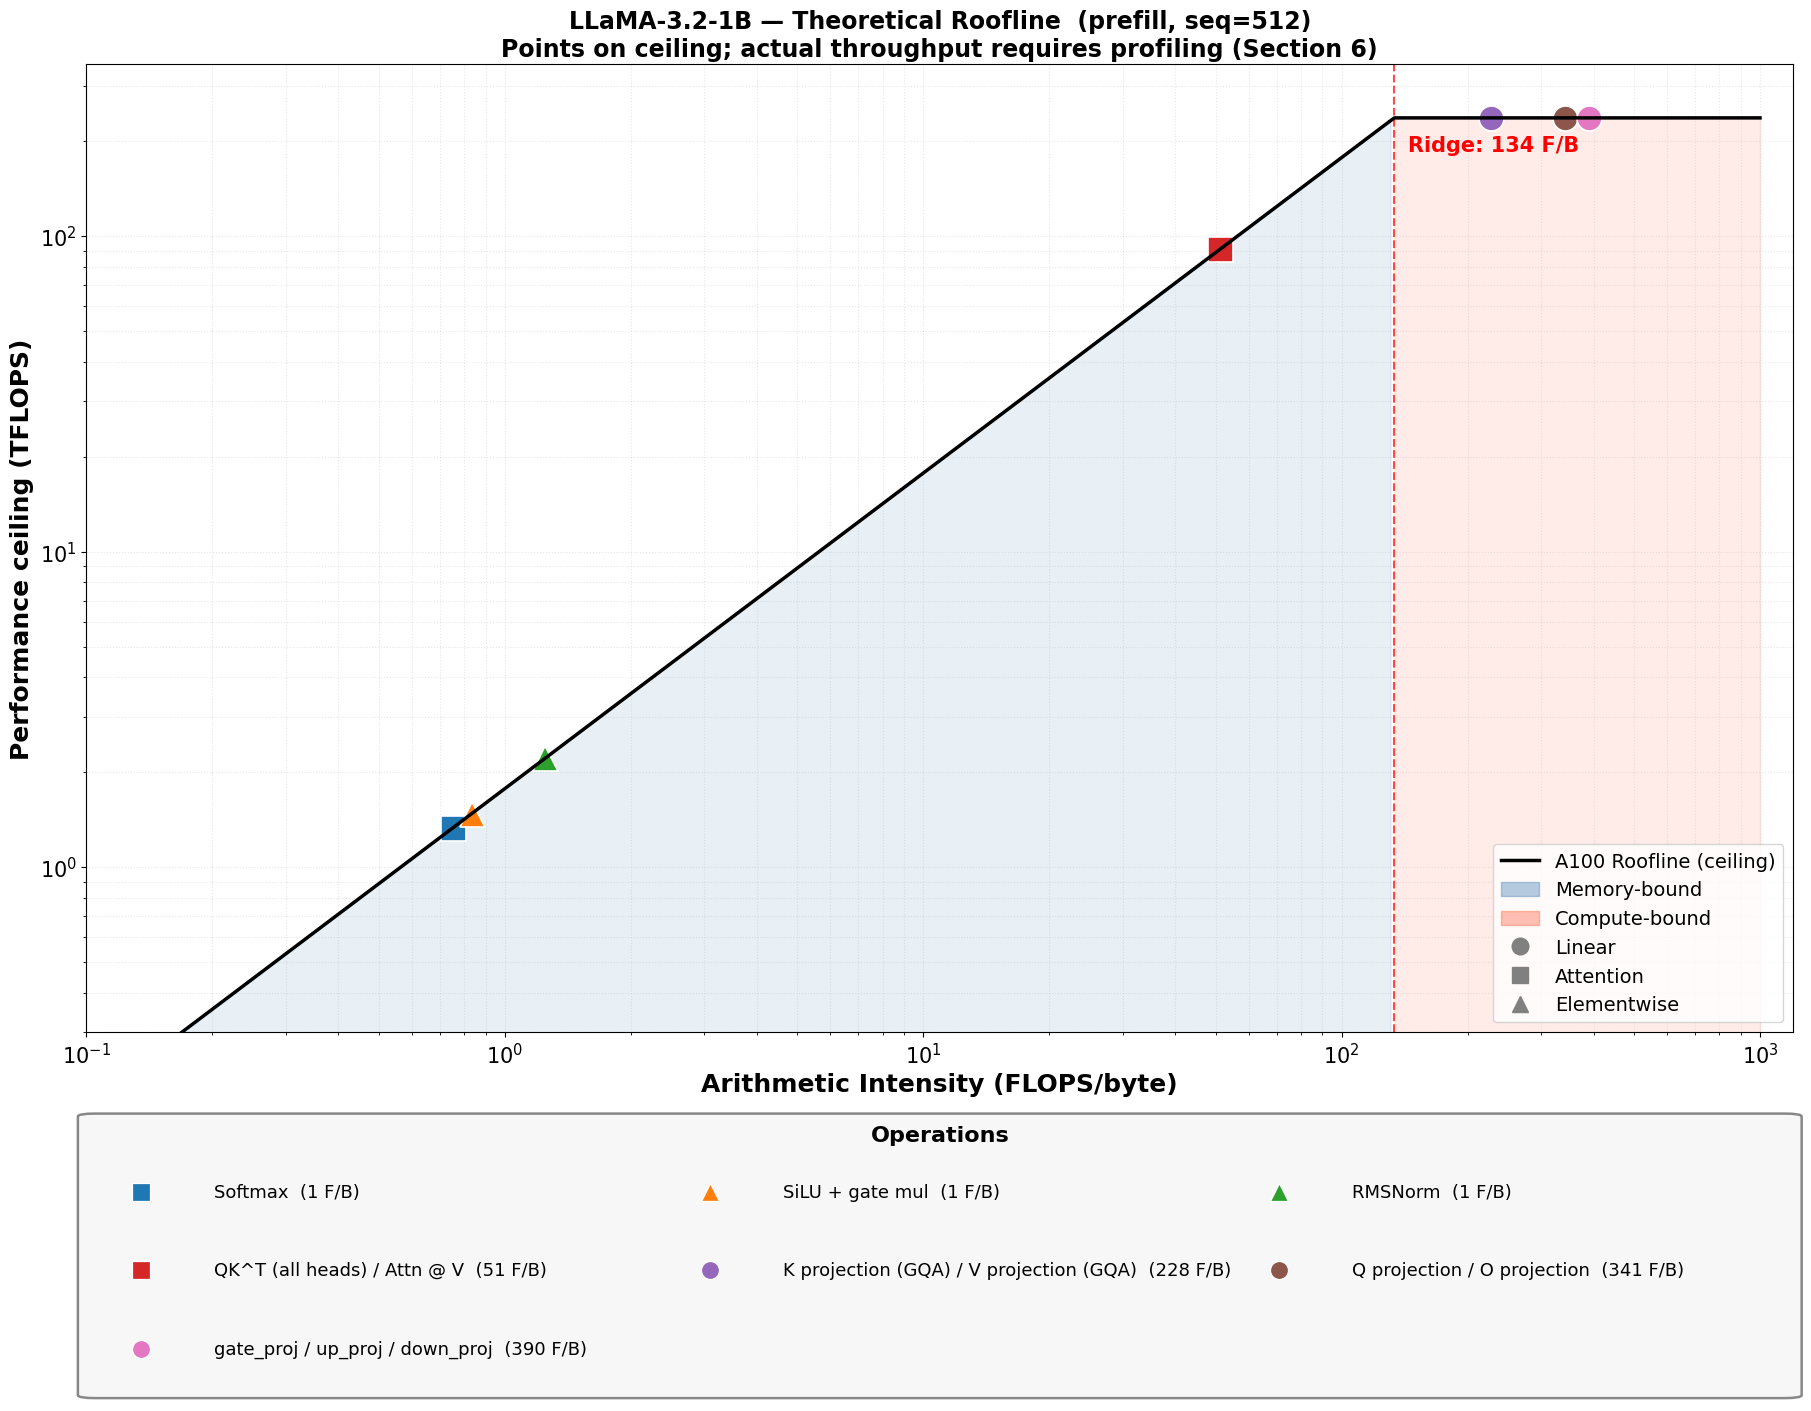

In [35]:
from collections import defaultdict
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

peak_bw, peak_tfl = 1774, 237          # GB/s, TFLOPS
ridge_point = peak_tfl * 1000 / peak_bw

plt.rcParams.update({'font.size': 15})

x_range = np.logspace(-1, 3, 500)
roof    = np.minimum(peak_bw * x_range / 1000, peak_tfl)

# layout='constrained' handles spacing automatically; avoids tight_layout warning on axis('off') panels
fig = plt.figure(figsize=(18, 14), layout='constrained')
ax, ax_leg = fig.add_gridspec(2, 1, height_ratios=[4, 1.2]).subplots()

# Roofline curve + shaded regions
ax.loglog(x_range, roof, 'k-', lw=2.5, zorder=10)
mem = x_range < ridge_point
ax.fill_between(x_range[mem],  roof[mem],  alpha=0.12, color='steelblue')
ax.fill_between(x_range[~mem], roof[~mem], alpha=0.12, color='tomato')
ax.axvline(ridge_point, color='red', ls='--', lw=1.5, alpha=0.7)
ax.text(ridge_point * 1.08, peak_tfl * 0.88, f'Ridge: {ridge_point:.0f} F/B',
        fontsize=15, color='red', fontweight='bold', va='top')

# Collapse identical-intensity ops to one point; place ON the roofline (= theoretical ceiling).
# Actual throughput depends on kernel implementation — profiler in Section 6 gives real numbers.
cat_markers = {'Linear': 'o', 'Attention': 's', 'Elementwise': '^'}
groups = defaultdict(list)
for _, row in df.iterrows():
    groups[round(row['Intensity'], 3)].append(row)
sorted_groups = sorted(groups.items())
colors = {k: c for (k, _), c in zip(sorted_groups, plt.cm.tab10.colors)}

entries = []
for intensity, grp in sorted_groups:
    names = [r['Operation'] for r in grp]
    label = (names[0] if len(names) == 1
             else ' / '.join(names) if len(names) == 2
             else ' / '.join(n.replace('FFN ', '').replace(' (GQA)', '') for n in names))
    color, cat = colors[intensity], grp[0]['Category']
    ax.loglog(intensity, min(peak_bw * intensity / 1000, peak_tfl),
              marker=cat_markers[cat], ms=18, color=color, mec='white', mew=1.2, zorder=5, ls='none')
    entries.append((color, cat_markers[cat], label, intensity))

ax.set_xlabel('Arithmetic Intensity (FLOPS/byte)', fontsize=18, fontweight='bold')
ax.set_ylabel('Performance ceiling (TFLOPS)',       fontsize=18, fontweight='bold')
ax.set_title('LLaMA-3.2-1B — Theoretical Roofline  (prefill, seq=512)\n'
             'Points on ceiling; actual throughput requires profiling (Section 6)',
             fontsize=17, fontweight='bold')
ax.tick_params(labelsize=15)
ax.grid(True, which='both', alpha=0.3, ls=':')
ax.set_xlim(0.1, 1200); ax.set_ylim(0.3, 350)
ax.legend(handles=[
    plt.Line2D([0],[0], ls='-',  color='black',     lw=2.5,        label='A100 Roofline (ceiling)'),
    mpatches.Patch(color='steelblue', alpha=0.4,                    label='Memory-bound'),
    mpatches.Patch(color='tomato',    alpha=0.4,                    label='Compute-bound'),
    plt.Line2D([0],[0], marker='o', color='gray', ls='none', ms=12, label='Linear'),
    plt.Line2D([0],[0], marker='s', color='gray', ls='none', ms=12, label='Attention'),
    plt.Line2D([0],[0], marker='^', color='gray', ls='none', ms=12, label='Elementwise'),
], fontsize=14, loc='lower right')

# Bottom legend panel with bounding box
ax_leg.axis('off')
ax_leg.add_patch(FancyBboxPatch((0.005, 0.02), 0.99, 0.96, boxstyle='round,pad=0.01',
                                transform=ax_leg.transAxes, facecolor='#f7f7f7',
                                edgecolor='#888', lw=1.8, zorder=0, clip_on=False))
ax_leg.text(0.5, 0.95, 'Operations', fontsize=16, fontweight='bold',
            ha='center', va='top', transform=ax_leg.transAxes)

col_w, row_y = 1/3, [0.72, 0.45, 0.18]
for i, (color, mkr, label, intensity) in enumerate(entries):
    col_x = (i % 3) * col_w + 0.01   # renamed from x — avoids clobbering the input tensor x
    ax_leg.plot(col_x + 0.022, row_y[i // 3], marker=mkr, color=color, ms=13,
                transform=ax_leg.transAxes, clip_on=False, mec='white', mew=0.9)
    ax_leg.text(col_x + 0.065, row_y[i // 3], f"{label}  ({intensity:.0f} F/B)",
                fontsize=13, va='center', transform=ax_leg.transAxes)

plt.show()


## 5. Decode vs Prefill — How Intensity Changes

Everything above was **prefill** (seq=512 tokens processed in parallel). During **decode** (one token at a time), the picture changes dramatically.

The weight matrices are identical — but now only 1 token passes through instead of 512. The weights still need to be fully loaded from HBM; there's just far less compute to amortize them against.

Calculate the intensity for each projection in both phases and see what happens to the roofline position.

In [36]:
print("Same linear layer, different phases:")
print("="*70)
print(f"{'Operation':<30} {'Prefill (S=512)':>18} {'Decode (S=1)':>18}")
print("-"*70)

for op_name, M_prefill, K_dim, N_dim in [
    ('Q projection', S, D, D),
    ('K projection (GQA)', S, D, kv_dim),
    ('FFN gate_proj', S, D, D_ff),
    ('FFN down_proj', S, D_ff, D),
]:
    # Prefill: S tokens processed in parallel through the linear layer
    flops_pre = 2 * M_prefill * K_dim * N_dim  # YOUR CODE
    bytes_pre = (M_prefill*K_dim + K_dim*N_dim + M_prefill*N_dim) * 2  # YOUR CODE
    i_pre = flops_pre / bytes_pre

    # Decode: 1 token — same weight matrix, only M changes from S to 1
    flops_dec = 2 * 1 * K_dim * N_dim  # YOUR CODE
    bytes_dec = (1*K_dim + K_dim*N_dim + 1*N_dim) * 2  # YOUR CODE
    i_dec = flops_dec / bytes_dec

    print(f"{op_name:<30} {i_pre:>14.1f} F/B {i_dec:>14.1f} F/B")

print("-"*70)
print(f"{'Ridge point':<30} {'':>14} {ridge_point:>14.0f} F/B")
print()
print("During decode, EVERY operation drops below the ridge point.")
print("The entire model becomes memory-bound — this is why decode is slow.")

Same linear layer, different phases:
Operation                         Prefill (S=512)       Decode (S=1)
----------------------------------------------------------------------
Q projection                            341.3 F/B            1.0 F/B
K projection (GQA)                      227.6 F/B            1.0 F/B
FFN gate_proj                           390.1 F/B            1.0 F/B
FFN down_proj                           390.1 F/B            1.0 F/B
----------------------------------------------------------------------
Ridge point                                              134 F/B

During decode, EVERY operation drops below the ridge point.
The entire model becomes memory-bound — this is why decode is slow.


## 6. Profile to Verify

You've predicted which operations are memory-bound vs compute-bound from first principles. Now run the profiler and check if the **time breakdown** matches those predictions.

**What to look for:**
- Do **linear layers** (Q/K/V/O projections + FFN gate/up/down — all 7 GEMMs) take a smaller time share than their FLOPs share? They should — high intensity means the hardware is efficient.
- Does **attention** appear as a single `flash_fwd` kernel? Flash Attention fuses QK^T + softmax + @V into one — no separate softmax kernel.
- Do **elementwise ops** (near-zero intensity) punch above their weight in wall-clock time relative to their trivial FLOPs?


In [37]:
import re

# Warmup
with torch.no_grad():
    for _ in range(5):
        _ = block(x, position_embeddings=position_embeddings, use_cache=False)

# Profile the forward pass
with torch.no_grad():
    with profile(
        activities=[ProfilerActivity.CUDA],
        record_shapes=True,
        with_flops=True,
        with_stack=True
    ) as prof:
        output = block(x, position_embeddings=position_embeddings, use_cache=False)

# Version-safe accessor — attribute name changed across PyTorch 2.x releases
def _cuda_us(evt):
    for attr in ('self_cuda_time_total', 'self_device_time_total',
                 'cuda_time_total', 'device_time_total'):
        v = getattr(evt, attr, None)
        if v is not None:
            return v
    return 0

def _readable_kernel(key):
    """Convert cryptic CUDA kernel name to a short readable label."""
    n = key.lower()
    if 'flash_fwd' in n or 'flash_bwd' in n:
        return 'FlashAttn fwd  (QK · softmax · V  fused)'
    if any(k in n for k in ('gemm', 'cutlass', 'xmma', 'tensorop', 's16816')):
        tile     = re.search(r'(\d+x\d+(?:x\d+)?)', key)
        tile_str = tile.group(1) if tile else '?'
        fused    = ' +relu' if 'relu' in n else ''
        src      = 'cutlass' if 'cutlass' in n else ('xmma' if 'xmma' in n else 'ampere')
        return f'GEMM  ({src}  tile {tile_str}{fused})'
    if 'catarray' in n:         return 'cat  (concat K/V heads)'
    if 'reduce_kernel' in n:    return 'reduce  (RMSNorm: sum-of-squares)'
    if 'rsqrt' in n:            return 'rsqrt  (RMSNorm: normalize)'
    if 'direct_copy' in n:      return 'copy  (reshape / transpose)'
    if 'binaryfunc' in n:       return 'binary elem  (SiLU · gate → hidden)'
    if 'cudafuncto' in n:       return 'elem functor  (scale / add)'
    if any(k in n for k in ('vectorized_elementwise', 'unrolled_elementwise', 'elementwise_kernel')):
        return 'elementwise  (RMSNorm scale / residual add / misc)'
    return key[:70]

def _op_hint(readable, calls):
    """
    Best-guess model op for a GEMM kernel, inferred from tile size + call count.
    LLaMA-3.2-1B has 7 linear layers per block across 4 distinct tile shapes:
      tile 64x64         → K + V proj  (GQA narrow output: 2048→512),      2 calls
      tile 128x128       → Q + O proj  (square: 2048→2048),                 2 calls
      tile 256x64 +relu  → gate + up   (expand: 2048→8192, +fused act),     2 calls
      tile 96x128x32     → down_proj   (contract: 8192→2048, large K),      1 call
    """
    if 'GEMM' not in readable:
        return ''
    m = re.search(r'tile (\S+)', readable)
    if not m:
        return ''
    tile = m.group(1).rstrip(')')
    if '64x64' in tile:
        return 'K + V proj  (GQA: 2048→512)'
    if '128x128' in tile:
        return 'Q + O proj  (2048→2048)'
    if calls == 2:
        return 'gate + up proj  (2048→8192)'
    if calls == 1:
        return 'down_proj  (8192→2048)'
    return ''

events   = prof.key_averages()
total_us = sum(_cuda_us(e) for e in events)

rows = sorted(
    [{'Kernel':         _readable_kernel(e.key),
      'Op (inferred)':  _op_hint(_readable_kernel(e.key), e.count),
      'CUDA ms':        _cuda_us(e) / 1000,
      'Share %':        _cuda_us(e) / total_us * 100 if total_us else 0,
      'Calls':          e.count}
     for e in events if _cuda_us(e) > 0],
    key=lambda r: r['CUDA ms'], reverse=True
)

summary = pd.DataFrame(rows)
summary['CUDA ms'] = summary['CUDA ms'].map('{:.3f}'.format)
summary['Share %'] = summary['Share %'].map('{:.1f}%'.format)
print(f"Total CUDA time in prefill run: {total_us/1000:.3f} ms\n")
print(summary.to_string(index=False))
print("\n* 'Op (inferred)' is a best guess from tile size + call count — not ground truth")


Total CUDA time in prefill run: 0.744 ms

                                            Kernel               Op (inferred) CUDA ms Share %  Calls
                GEMM  (cutlass  tile 256x64 +relu) gate + up proj  (2048→8192)   0.234   31.4%      2
                      GEMM  (xmma  tile 96x128x32)      down_proj  (8192→2048)   0.118   15.8%      1
                      GEMM  (ampere  tile 128x128)     Q + O proj  (2048→2048)   0.076   10.2%      2
               binary elem  (SiLU · gate → hidden)                               0.047    6.3%      6
          FlashAttn fwd  (QK · softmax · V  fused)                               0.033    4.4%      1
                        GEMM  (ampere  tile 64x64) K + V proj  (GQA: 2048→512)   0.032    4.3%      2
                           cat  (concat K/V heads)                               0.025    3.4%      2
                 reduce  (RMSNorm: sum-of-squares)                               0.024    3.2%      2
                       copy  (reshape / 

In [42]:
# Pre-written: group kernel names into readable categories.
GEMM_KWS     = ['gemm', 'cutlass', 'xmma', 'tensorop']
ATTN_KWS     = ['flash', 'sdp', 'attention', 'softmax', 'bmm']
ELEMWISE_KWS = ['elementwise', 'vectorized', 'unrolled', 'reduce', 'cat']

# Check ATTN before GEMM — flash attention uses CUTLASS internally, so its kernel
# name contains 'cutlass' and would be misclassified as Linear if GEMM is checked first.
totals = {'Linear (all 7 GEMMs)': 0.0, 'Attention (Flash)': 0.0, 'Elementwise': 0.0, 'Other': 0.0}
for evt in prof.key_averages():
    name = evt.key.lower()
    t = _cuda_us(evt)
    if   any(k in name for k in ATTN_KWS):      totals['Attention (Flash)'] += t
    elif any(k in name for k in GEMM_KWS):       totals['Linear (all 7 GEMMs)'] += t
    elif any(k in name for k in ELEMWISE_KWS):   totals['Elementwise'] += t
    else:                                         totals['Other'] += t

total = sum(totals.values())
print(f"Time breakdown (seq={seq_len}, prefill, batch=1):\n")
print(f"  {'Category':<22}  {'µs':>8}  {'ms':>7}  {'Share':>7}")
print(f"  {'-'*50}")
for cat in ['Linear (all 7 GEMMs)', 'Attention (Flash)', 'Elementwise', 'Other']:
    us = totals[cat]
    print(f"  {cat:<22}  {us:>8.1f}  {us/1000:>7.3f}  {us/total*100:>6.1f}%")
print(f"  {'-'*50}")
print(f"  {'TOTAL':<22}  {total:>8.1f}  {total/1000:>7.3f}  {'100.0%':>7}")


Time breakdown (seq=512, prefill, batch=1):

  Category                      µs       ms    Share
  --------------------------------------------------
  Linear (all 7 GEMMs)       460.0    0.460    61.8%
  Attention (Flash)           32.8    0.033     4.4%
  Elementwise                251.5    0.252    33.8%
  Other                        0.0    0.000     0.0%
  --------------------------------------------------
  TOTAL                      744.4    0.744   100.0%


**Why does elementwise take more time than attention?**

Flash Attention is one highly-fused kernel — it computes QK^T + softmax + @V without ever writing the S×S score matrix to HBM. One kernel, ~32 µs, done.

Elementwise ops are ~20 separate unfused kernel launches. Each RMSNorm alone is 3–4 kernels (reduce → rsqrt → scale → add), and every one does a full HBM round-trip for trivially few FLOPs. Near-zero arithmetic intensity means almost all of that time is bandwidth-limited waiting, not compute.

This is why **kernel fusion** is one of the highest-leverage optimisations in LLM serving — fusing RMSNorm, SiLU, and residual adds into their neighbouring linear kernels collapses ~20 kernel launches into a handful, eliminating most of those HBM round-trips. Flash Attention is the canonical proof: it got ~10× faster vs unfused attention not by doing less work, but by fusing three ops and tiling to avoid writing O(S²) intermediates to HBM.


## Revision Notes

*Fill this in after running all sections.*

---

**Time breakdown** (from Section 6 profiler):
- Linear layers: 62%
- Attention: 4%
- Elementwise: 34%

**Intensity by operation type (prefill, seq=512):**
- FFN projections: 390 FLOPS/byte → compute-bound
- Q/O projections: 341 FLOPS/byte → compute-bound
- K/V projections (GQA): 227 FLOPS/byte → compute-bound
- Softmax: 0.75 FLOPS/byte → memory-bound
- RMSNorm/SiLU: 1.25/0.8 FLOPS/byte → memory-bound

**Key insight about decode vs prefill:**
With batch size 1, I though at least all linear projections would be compute bound or very close to the ridge point. But it seems almost everything is having an intensoty of 1 flop per byte - all  linear projections and also the attention score calcualtion. So batch size is very important in order to obtain higher GPU utilization during decode phase. In prefill phase, the high linear intensity masks the bandwidth limiatations of copying linear projection  from HBM.

**What surprised me:**
How attention kernel takes much less total CUDA time than other element wise ops. And How flash attention significantly even further.

---

### Key Insights

1. **During prefill, large linear layers are compute-bound** (~300+ FLOPS/byte)
   Seq=512 means the weight matrix is reused 512 times — amortized HBM cost → tensor cores run hot.

2. **During decode, everything becomes memory-bound** (~1 FLOP/byte)
   One token = weight matrix used once → weights dominate bytes → GPU compute <1% utilised.

3. **GQA K/V projections are less compute-bound than Q/O**
   4× smaller weight matrices → less amortization → lower intensity. Deliberate tradeoff for KV cache savings (Chapter 3).

4. **Flash Attention fuses QK^T + softmax + @V into one kernel**
   No S×S score matrix written to HBM. The profiler shows one `flash_fwd` kernel, not three separate ops.

5. **Elementwise ops (RMSNorm, SiLU) are severely memory-bound**
   ~1-2 FLOPS/byte. The fix: fuse them into adjacent kernels (Chapter 6).

---
*Next: Chapter 3 — KV Cache & Attention Variants*

## Knowledge Check

Test yourself before moving on. Answer from memory and reasoning — no peeking at cells above.

- **Calculation questions** use LLaMA-3.2-1B dimensions (d_model=2048, d_ff=8192, 32 Q heads, 8 KV heads, d_head=64)
- **Conceptual questions** test whether you can connect profiling results to optimization strategies
- **Trap questions** catch common misconceptions about what helps decode

Fill in each `None  # YOUR ANSWER` below, then run the checker cell to see your score.

In [49]:
# ============================================================
# KNOWLEDGE CHECK — Chapter 2: Profiling a Transformer Block
# ============================================================
# Answer each question, then run the next cell to check.
# Use LLaMA-3.2-1B dimensions: d_model=2048, d_ff=8192, 32 Q heads, 8 KV heads, d_head=64

# --- Calculation ---

# Q1: How many linear layers are in ONE transformer block?
#     (Count attention projections + SwiGLU FFN projections)
q1 = 4 + 3  # YOUR ANSWER (integer)

# Q2: How many KV heads does LLaMA-3.2-1B use? (GQA)
q2 = 32 / 4  # YOUR ANSWER (integer)

# Q3: Q projection at prefill (seq=512): (512, 2048) @ (2048, 2048).
#     What is its arithmetic intensity? (FP16, count input + weight + output bytes)
q3 = (2 * 512 * 2048 * 2048) / ((512*2048 + 2048*2048 + 512*2048) * 2)  # YOUR ANSWER (FLOPS/byte)

# Q4: Same Q projection during DECODE (seq=1): (1, 2048) @ (2048, 2048).
#     What is its arithmetic intensity now?
q4 = (2 * 1 * 2048 * 2048) / ((1*2048 + 2048*2048 + 1*2048) * 2) # YOUR ANSWER (FLOPS/byte)

# Q5: Softmax reads and writes the full S×S score matrix for every head.
#     At seq=512 with 32 heads in FP16, how many MB does softmax touch?
#     (read + write = 2 passes over the data)
q5 = 2 * (32 * 512 * 512 * 2) / 1e6  # YOUR ANSWER (MB)

# --- Conceptual ---

# Q6: Match each bottleneck to the optimization that fixes it.
#     Answer with the exact string shown.
#
#     a) Unfused elementwise ops (RMSNorm, SiLU) waste HBM bandwidth
q6a = "kernel fusion"  # YOUR ANSWER: "kernel fusion", "flash attention", or "quantization"
#
#     b) Attention writes O(S²) intermediate scores to HBM
q6b = "flash attention"  # YOUR ANSWER: "kernel fusion", "flash attention", or "quantization"
#
#     c) Decode loads ~2.5 GB of weights per token at batch=1
q6c = "quantization"  # YOUR ANSWER: "kernel fusion", "flash attention", or "quantization"

# --- Trap / misconception ---

# Q7: SwiGLU uses 3 FFN projections (gate, up, down) instead of standard FFN's 2.
#     Across all 16 blocks, how many EXTRA linear layers does SwiGLU add vs standard FFN?
q7 = 1 * 16  # YOUR ANSWER (integer — total extra layers across the whole model)

# Q8: You upgrade to a GPU with 2x the TFLOPS (474 TFLOPS) but same bandwidth (1774 GB/s).
#     Does batch=1 decode get faster?
q8 = "no"  # YOUR ANSWER: "yes" or "no"

In [50]:
# ============================================================
# RUN THIS CELL TO CHECK YOUR ANSWERS (do not modify)
# ============================================================
def _check(label, got, expected, tol=0.1):
    if got is None:
        print(f"  ✗ {label}: not answered")
        return 0
    if isinstance(expected, str):
        ok = got.strip().lower() == expected.strip().lower()
    else:
        ok = abs(got - expected) / max(abs(expected), 1e-9) <= tol
    print(f"  {'✓' if ok else '✗'} {label}" + ("" if ok else " — try again"))
    return int(ok)

_score = 0
_total = 10
print("Knowledge Check Results:\n")

_score += _check("Q1: Linear layers per block", q1, 7)
_score += _check("Q2: KV heads", q2, 8)

_f = 2 * 512 * 2048 * 2048
_b = (512 * 2048 + 2048 * 2048 + 512 * 2048) * 2
_score += _check("Q3: Q proj intensity (prefill)", q3, _f / _b)

_f = 2 * 1 * 2048 * 2048
_b = (1 * 2048 + 2048 * 2048 + 1 * 2048) * 2
_score += _check("Q4: Q proj intensity (decode)", q4, _f / _b)

_sb = 2 * 32 * 512 * 512 * 2
_score += _check("Q5: Softmax bytes (MB)", q5, _sb / 1e6)

_score += _check("Q6a: Fix for elementwise waste", q6a, "kernel fusion")
_score += _check("Q6b: Fix for O(S²) attention", q6b, "flash attention")
_score += _check("Q6c: Fix for weight loading", q6c, "quantization")

_score += _check("Q7: Extra layers from SwiGLU", q7, 16)
_score += _check("Q8: 2x TFLOPS helps decode?", q8, "no")

print(f"\nScore: {_score}/{_total}")
if _score == _total:
    print("Perfect — you're ready for Chapter 3!")
elif _score >= 7:
    print("Good — review the questions you missed before moving on.")
else:
    print("Review the notebook sections above and try again.")

Knowledge Check Results:

  ✓ Q1: Linear layers per block
  ✓ Q2: KV heads
  ✓ Q3: Q proj intensity (prefill)
  ✓ Q4: Q proj intensity (decode)
  ✓ Q5: Softmax bytes (MB)
  ✓ Q6a: Fix for elementwise waste
  ✓ Q6b: Fix for O(S²) attention
  ✓ Q6c: Fix for weight loading
  ✓ Q7: Extra layers from SwiGLU
  ✓ Q8: 2x TFLOPS helps decode?

Score: 10/10
Perfect — you're ready for Chapter 3!
